In [213]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

In [214]:
# Fuzzy Ranges

universe = np.arange(0.0, 1.05, 0.05)
distance = ctrl.Antecedent(universe, 'distance')
roughness = ctrl.Antecedent(universe, 'roughness')
elevation = ctrl.Antecedent(universe, 'elevation')

route_quality = ctrl.Consequent(universe, 'route_quality')

In [215]:
# Membership Functions

# Distance
distance['short'] = fuzz.trimf(universe, [0.0, 0.0, 0.35])
distance['average'] = fuzz.trimf(universe, [0.35, 0.5, 0.65])
distance['long'] = fuzz.trimf(universe, [0.65, 1.0, 1.0])

# Roughness
roughness['even'] = fuzz.trimf(universe, [0.0, 0.0, 0.5])
roughness['normal'] = fuzz.trimf(universe, [0.0, 0.5, 1.0])
roughness['uneven'] = fuzz.trimf(universe, [0.5, 1.0, 1.0])

# Elevation
elevation['flat'] = fuzz.trimf(universe, [0.0, 0.0, 0.75])
elevation['hilly'] = fuzz.trimf(universe, [0.25, 1.0, 1.0])

# Output
route_quality['low'] = fuzz.trimf(universe, [0.0, 0.0, 0.5])
route_quality['standard'] = fuzz.trimf(universe, [0.25, 0.5, 0.75])
route_quality['high'] = fuzz.trimf(universe, [0.5, 1.0, 1.0])

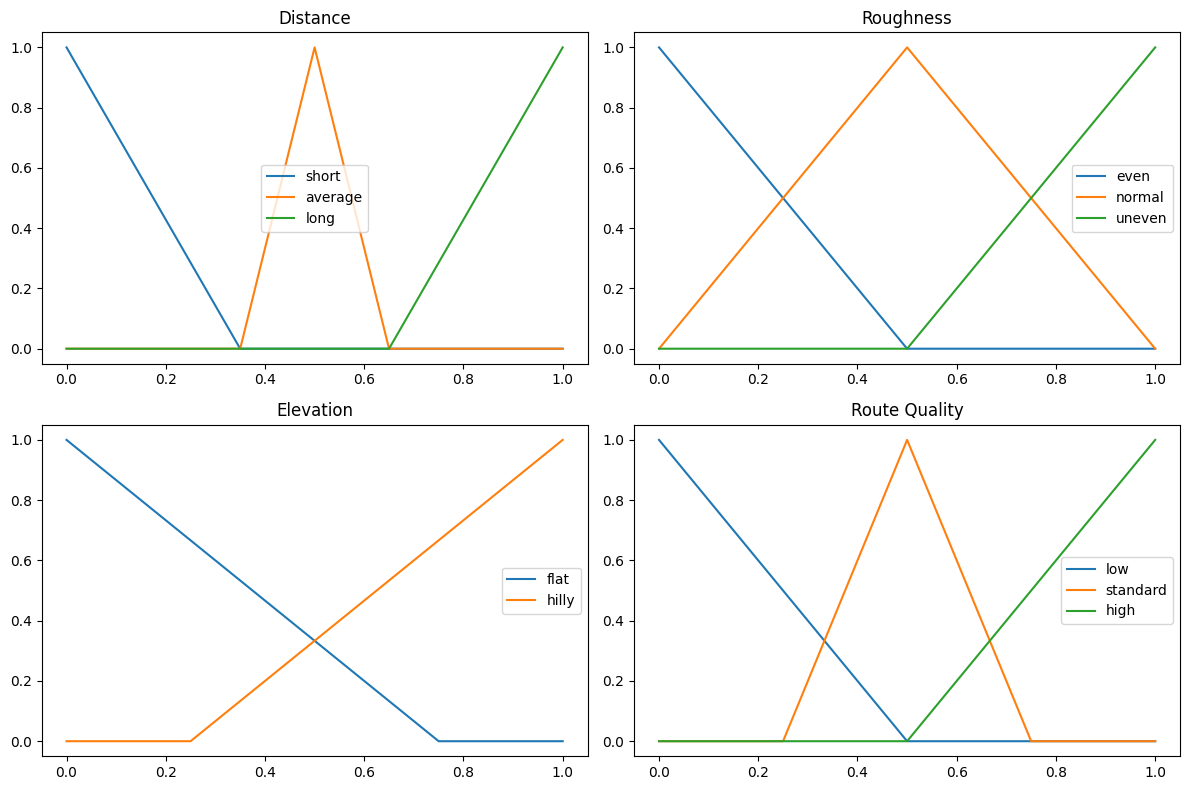

In [216]:
def plot_fis(variables):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    titles = ['Distance', 'Roughness', 'Elevation', 'Route Quality']

    for ax, var, title in zip(axes, variables, titles):
        for term in var.terms:
            ax.plot(
                var.universe,
                var[term].mf,
                label=term)

        ax.set_title(title)
        ax.set_ylim(-0.05, 1.05)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_fis([distance, roughness, elevation, route_quality])

In [217]:
# FIS Rules

rule1 = ctrl.Rule(
    distance['short'] & elevation['flat'] & roughness['even'],
    route_quality['high']
)
rule2 = ctrl.Rule(
    distance['average'] & roughness['normal'],
    route_quality['standard']
)
rule3 = ctrl.Rule(
    distance['long'] & elevation['hilly'] & roughness['uneven'],
    route_quality['low']
)

In [218]:
# Control System

route_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
route_sim = ctrl.ControlSystemSimulation(route_ctrl)

In [219]:
 # Route Quality Evaluation

dist_range = (1146, 1393)
elev_range = (33.72, 42.48)
rough_range = (1053, 1426)


def min_max_norm(x, x_range):
    return (x - x_range[0]) / (x_range[1] - x_range[0])


def calculate_memberships(x_universe, x):
    fig, ax = plt.subplots(figsize=(6, 4))
    for label, term in x_universe.terms.items():
        ax.plot(x_universe.universe, term.mf, label=label)
        membership = fuzz.interp_membership(
            x_universe.universe,
            term.mf,
            x)
        ax.fill_between(x_universe.universe, 0, np.minimum(term.mf, membership), alpha=0.3)
        print(f'- {label}: {round(float(membership), 2)}')
    ax.axvline(x, color='k', linestyle='--', label='input')
    ax.set_title(x_universe.label)
    ax.legend()
    plt.show()

In [220]:
x_distance = 1146
x_elevation = 37.42
x_roughness = 1205

In [221]:
dist_norm = min_max_norm(x_distance, dist_range)
elev_norm = min_max_norm(x_elevation, elev_range)
rough_norm = min_max_norm(x_roughness, rough_range)

route_sim.input['distance'] = dist_norm
route_sim.input['elevation'] = elev_norm
route_sim.input['roughness'] = rough_norm
route_sim.compute()

Distance: 0.0
- short: 1.0
- average: 0.0
- long: 0.0


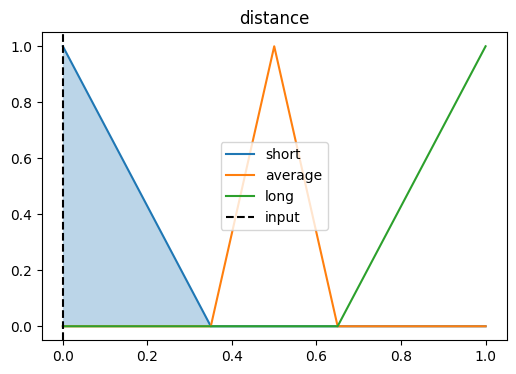

In [222]:
print('Distance:', round(float(dist_norm), 2))
calculate_memberships(distance, x=dist_norm)

Roughness: 0.41
- even: 0.18
- normal: 0.82
- uneven: 0.0


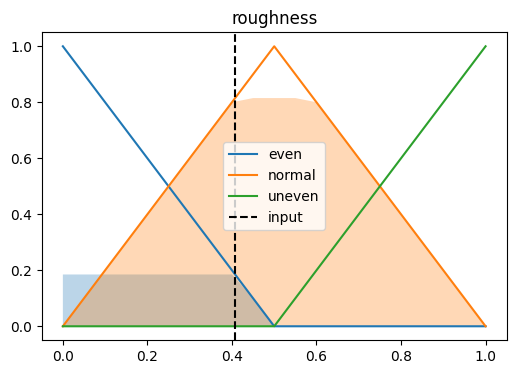

In [223]:
print('Roughness:', round(float(rough_norm), 2))
calculate_memberships(roughness, x=rough_norm)

Elevation: 0.42
- flat: 0.44
- hilly: 0.23


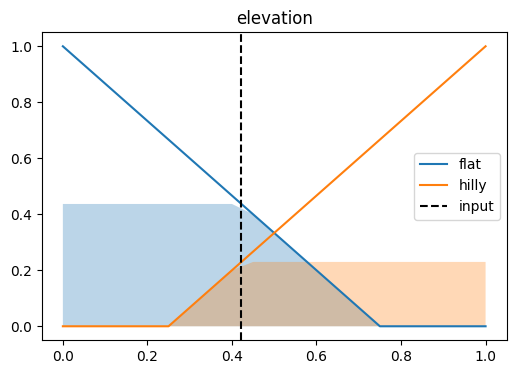

In [224]:
print('Elevation:', round(float(elev_norm), 2))
calculate_memberships(elevation, x=elev_norm)

In [225]:
print(f'Route Quality: {float(route_sim.output["route_quality"]):.2f}')

Route Quality: 0.77
